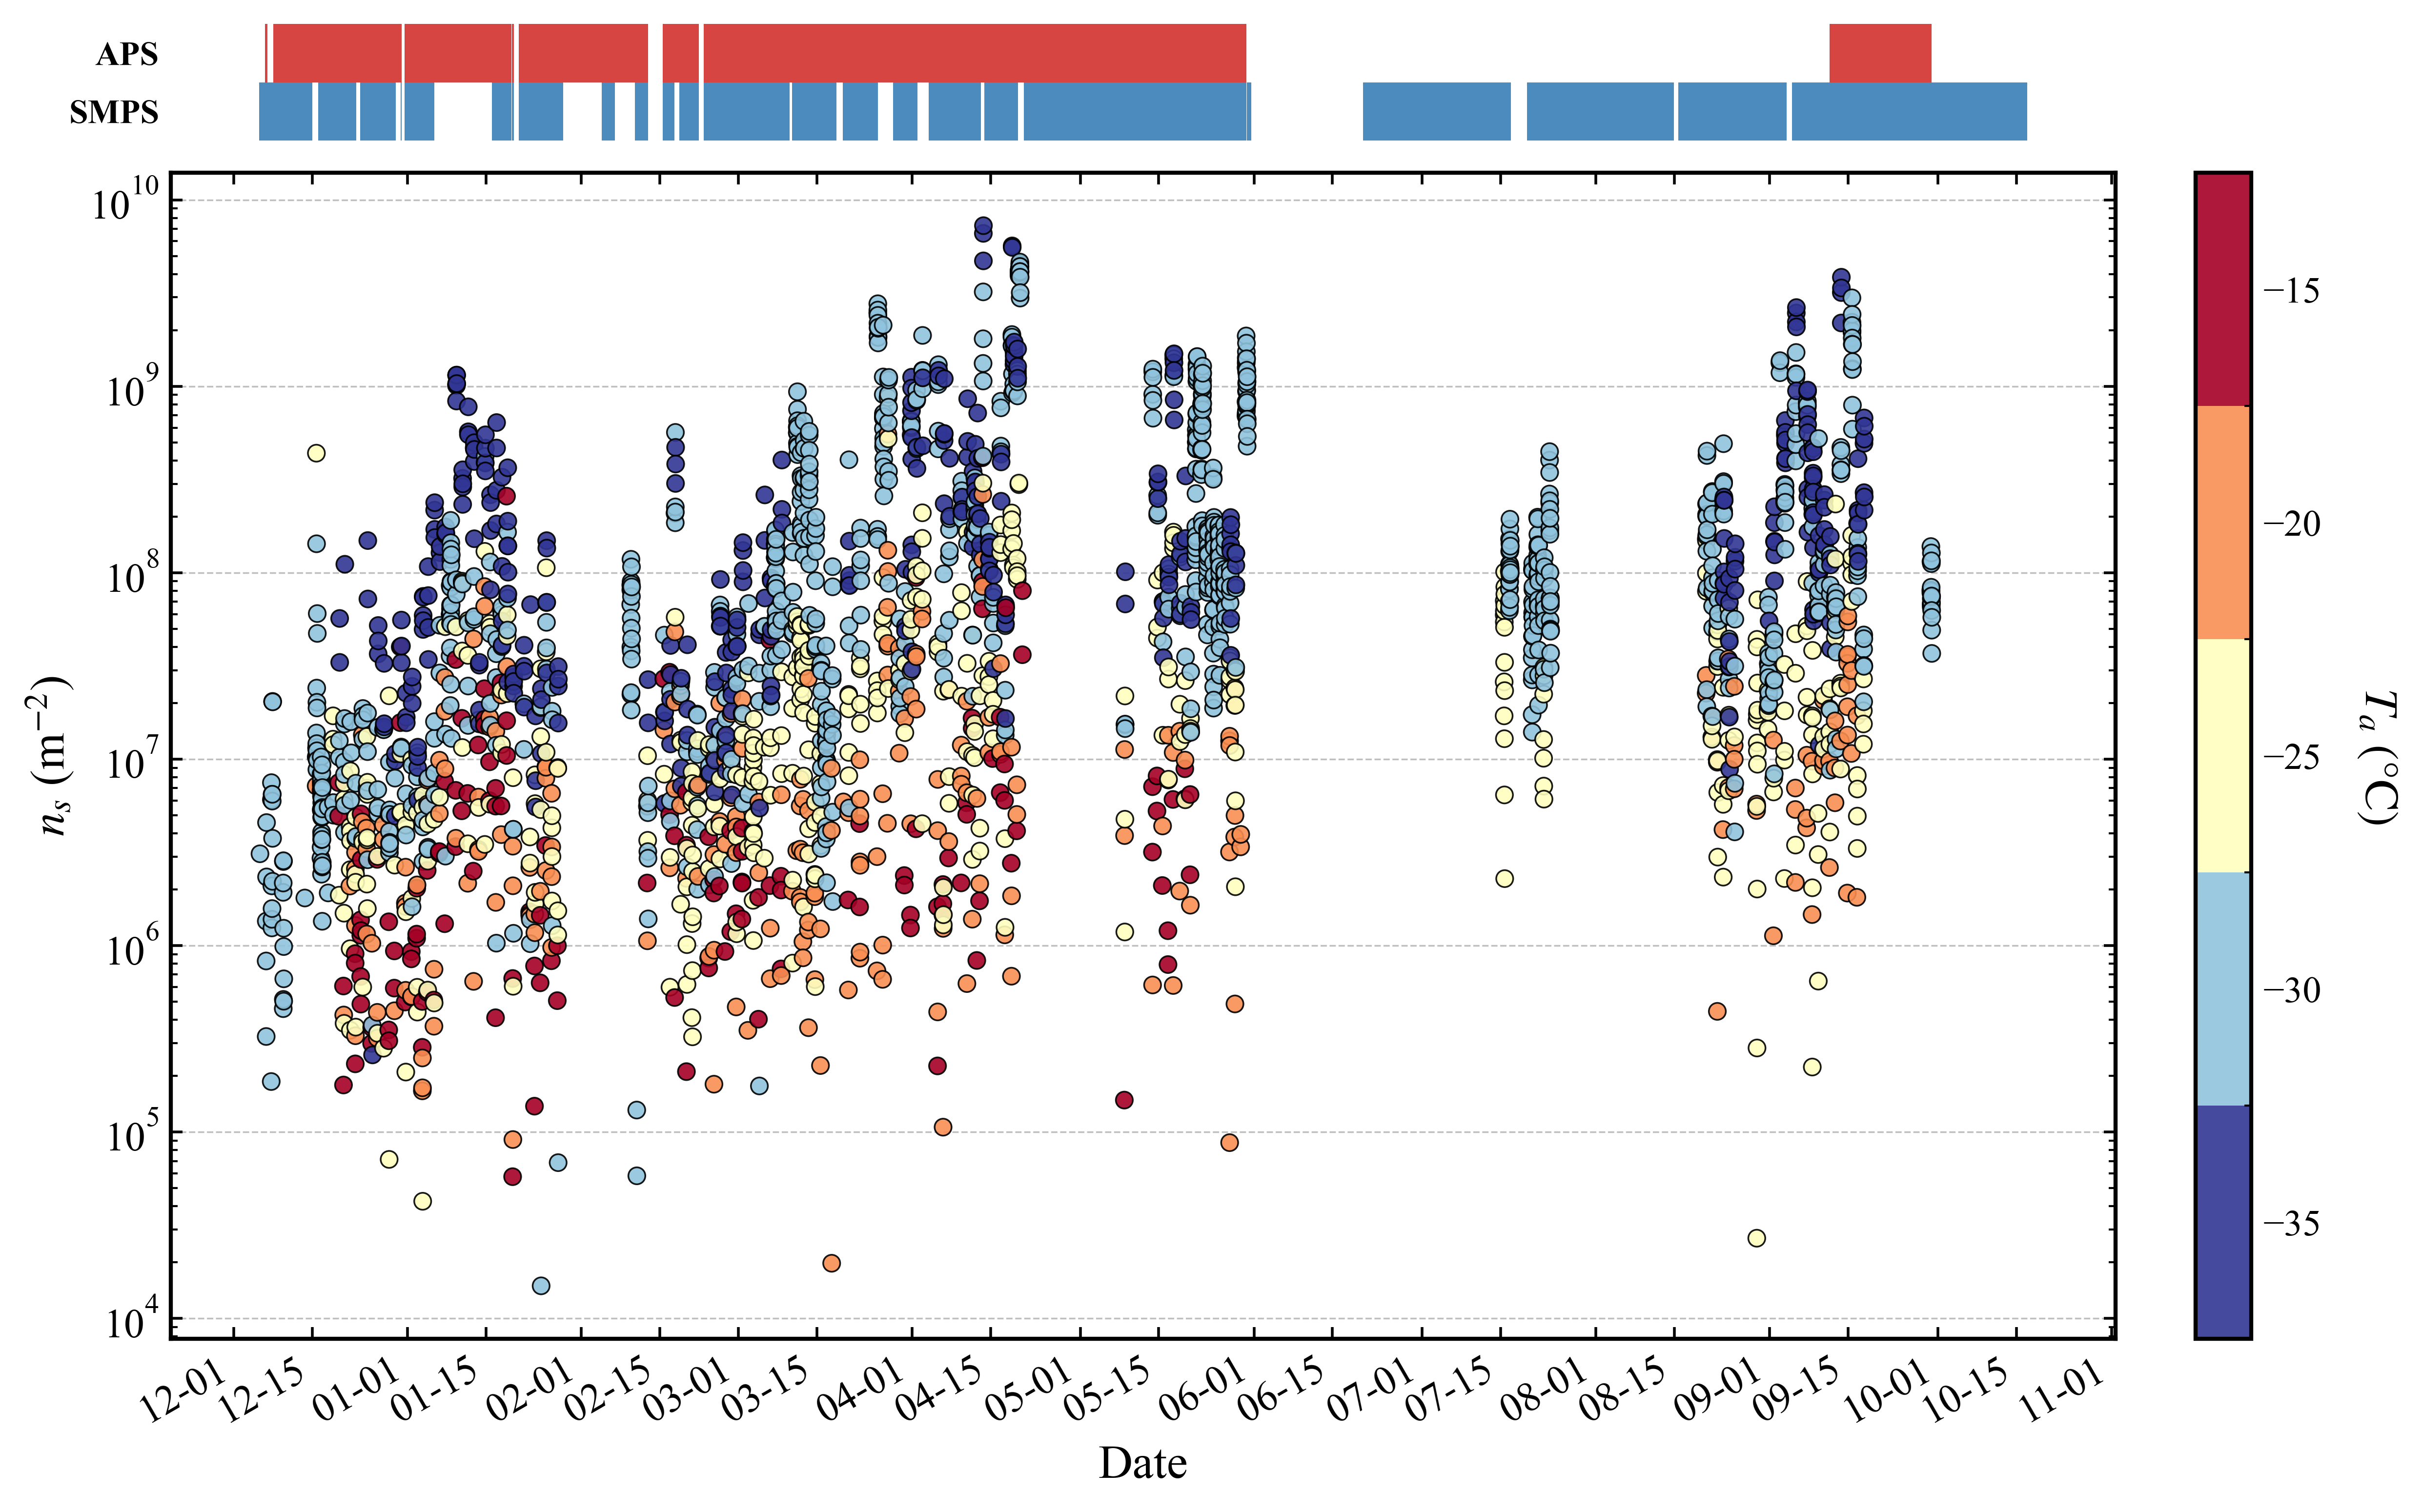

In [1]:
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker

# ==================== 1. 数据读取 ====================
final_psd_df = pd.read_csv(r"D:\Coding\Data\Lanzhou_aerosol\SMPS+APS\final_psd(v1.0.1).csv", index_col=0, parse_dates=True)
status_df = pd.read_csv(r"D:\Coding\Data\Lanzhou_aerosol\SMPS+APS\instrument_status(v1.0.1).csv", index_col=0, parse_dates=True)
result = pd.read_csv(r"D:\Coding\Data\Lanzhou_aerosol\SMPS+APS\INP+ns(v1.0.1).csv", parse_dates=['Date'])
status_smps = status_df['status_smps']
status_aps = status_df['status_aps']

# ==================== 2. 全局绘图风格设置 (论文级) ====================
config = {
    "font.family": 'serif',
    "font.serif": ['Times New Roman'],  # 论文标准字体
    "mathtext.fontset": 'stix',         # 数学公式字体与 Times 匹配
    "font.size": 12,
    "axes.linewidth": 1.2,              # 边框加粗
    "xtick.direction": 'in',            # 刻度向内
    "ytick.direction": 'in',
    "xtick.top": True,                  # 上下左右都有刻度
    "ytick.right": True,
    "xtick.minor.visible": False,        # 不显示次刻度
    "ytick.minor.visible": False
}
plt.rcParams.update(config)

# ==================== 3. 布局定义 ====================
# 使用 GridSpec 将画布分为 2行 x 2列
# 第一列放主图，第二列放 Colorbar (宽度很窄)
# 第一行放 Status，第二行放 Main Plot
fig = plt.figure(figsize=(11, 7), dpi=500) # 提高分辨率
gs = fig.add_gridspec(2, 2, 
                      width_ratios=[35, 1],   # 主图:色条宽度比
                      height_ratios=[1, 10],  # 状态条:主图高度比
                      wspace=0.08,            # 左右间距
                      hspace=0.05)            # 上下间距

ax_status = fig.add_subplot(gs[0, 0])
ax_main = fig.add_subplot(gs[1, 0], sharex=ax_status)
cax = fig.add_subplot(gs[1, 1])       # Colorbar 专用轴

# ==================== 4. 绘制顶部仪器状态条 ====================
dt_median = final_psd_df.index.to_series().diff().median()
bar_width = (dt_median.total_seconds() / 86400) * 1.02 

# 选用更柔和专业的颜色
c_smps = '#4B8BBE' # 柔和蓝
c_aps = '#D64541'  # 柔和红

ax_status.bar(final_psd_df.index[status_smps], height=1, bottom=0, 
              width=bar_width, color=c_smps, edgecolor='none', align='center')
ax_status.bar(final_psd_df.index[status_aps], height=1, bottom=1, 
              width=bar_width, color=c_aps, edgecolor='none', align='center')

# 美化状态条
ax_status.set_ylim(0, 2)
ax_status.set_yticks([0.5, 1.5])
ax_status.set_yticklabels(['SMPS', 'APS'], fontsize=10, fontweight='bold')
ax_status.tick_params(left=False, right=False, labelbottom=False, bottom=False, top=False) # 隐藏刻度线
# 只保留左侧文字，隐藏边框
for spine in ['top', 'right', 'left', 'bottom']:
    ax_status.spines[spine].set_visible(False)
ax_status.tick_params(left=False, bottom=False) 
# ==================== 5. 绘制主散点图 ====================

# --- 颜色映射逻辑 ---
# 温度点: -35, -30, -25, -20, -15
# 区间边界: [-37.5, -32.5, -27.5, -22.5, -17.5, -12.5]
bounds = [-37.5, -32.5, -27.5, -22.5, -17.5, -12.5]
# 使用 Spectral_r (反转光谱色): 红(暖) -> 蓝(冷)
# 也可以用 'RdYlBu_r'
cmap = plt.get_cmap('RdYlBu_r', 5) 
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# 绘制散点
sc = ax_main.scatter(result['Date'], result['n_s'], 
                     c=result['T_a(°C)'], cmap=cmap, norm=norm, 
                     s=25, alpha=0.9, edgecolors='black', linewidth=0.5, zorder=3)

# 设置坐标轴标签 (使用 LaTeX 格式)
ax_main.set_ylabel(r"$n_s$ ($\mathrm{m}^{-2}$)", fontsize=14)
ax_main.set_xlabel("Date", fontsize=14)
ax_main.set_yscale('log')

# 设置 X 轴日期格式
ax_main.xaxis.set_major_locator(mdates.DayLocator(bymonthday=[1, 15]))
ax_main.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(ax_main.xaxis.get_majorticklabels(), rotation=30, ha='right') # 旋转标签防止重叠

# 添加网格线 (灰色虚线，不抢眼)
ax_main.grid(which='major', axis='y', linestyle='--', linewidth=0.5, color='gray', alpha=0.5)

# ==================== 6. 绘制右侧离散 Colorbar ====================
cbar = plt.colorbar(sc, cax=cax, ticks=[-35, -30, -25, -20, -15])
cbar.set_label(r'$T_a \ (\degree \mathrm{C})$', fontsize=14, labelpad=10, rotation=270, va='bottom')
# 将 Colorbar 的 ticks 放在色块中心，并设置字体
cbar.ax.tick_params(labelsize=11, length=0) # length=0 隐藏刻度线，只留数字

plt.show()

## 仅含显著数据点

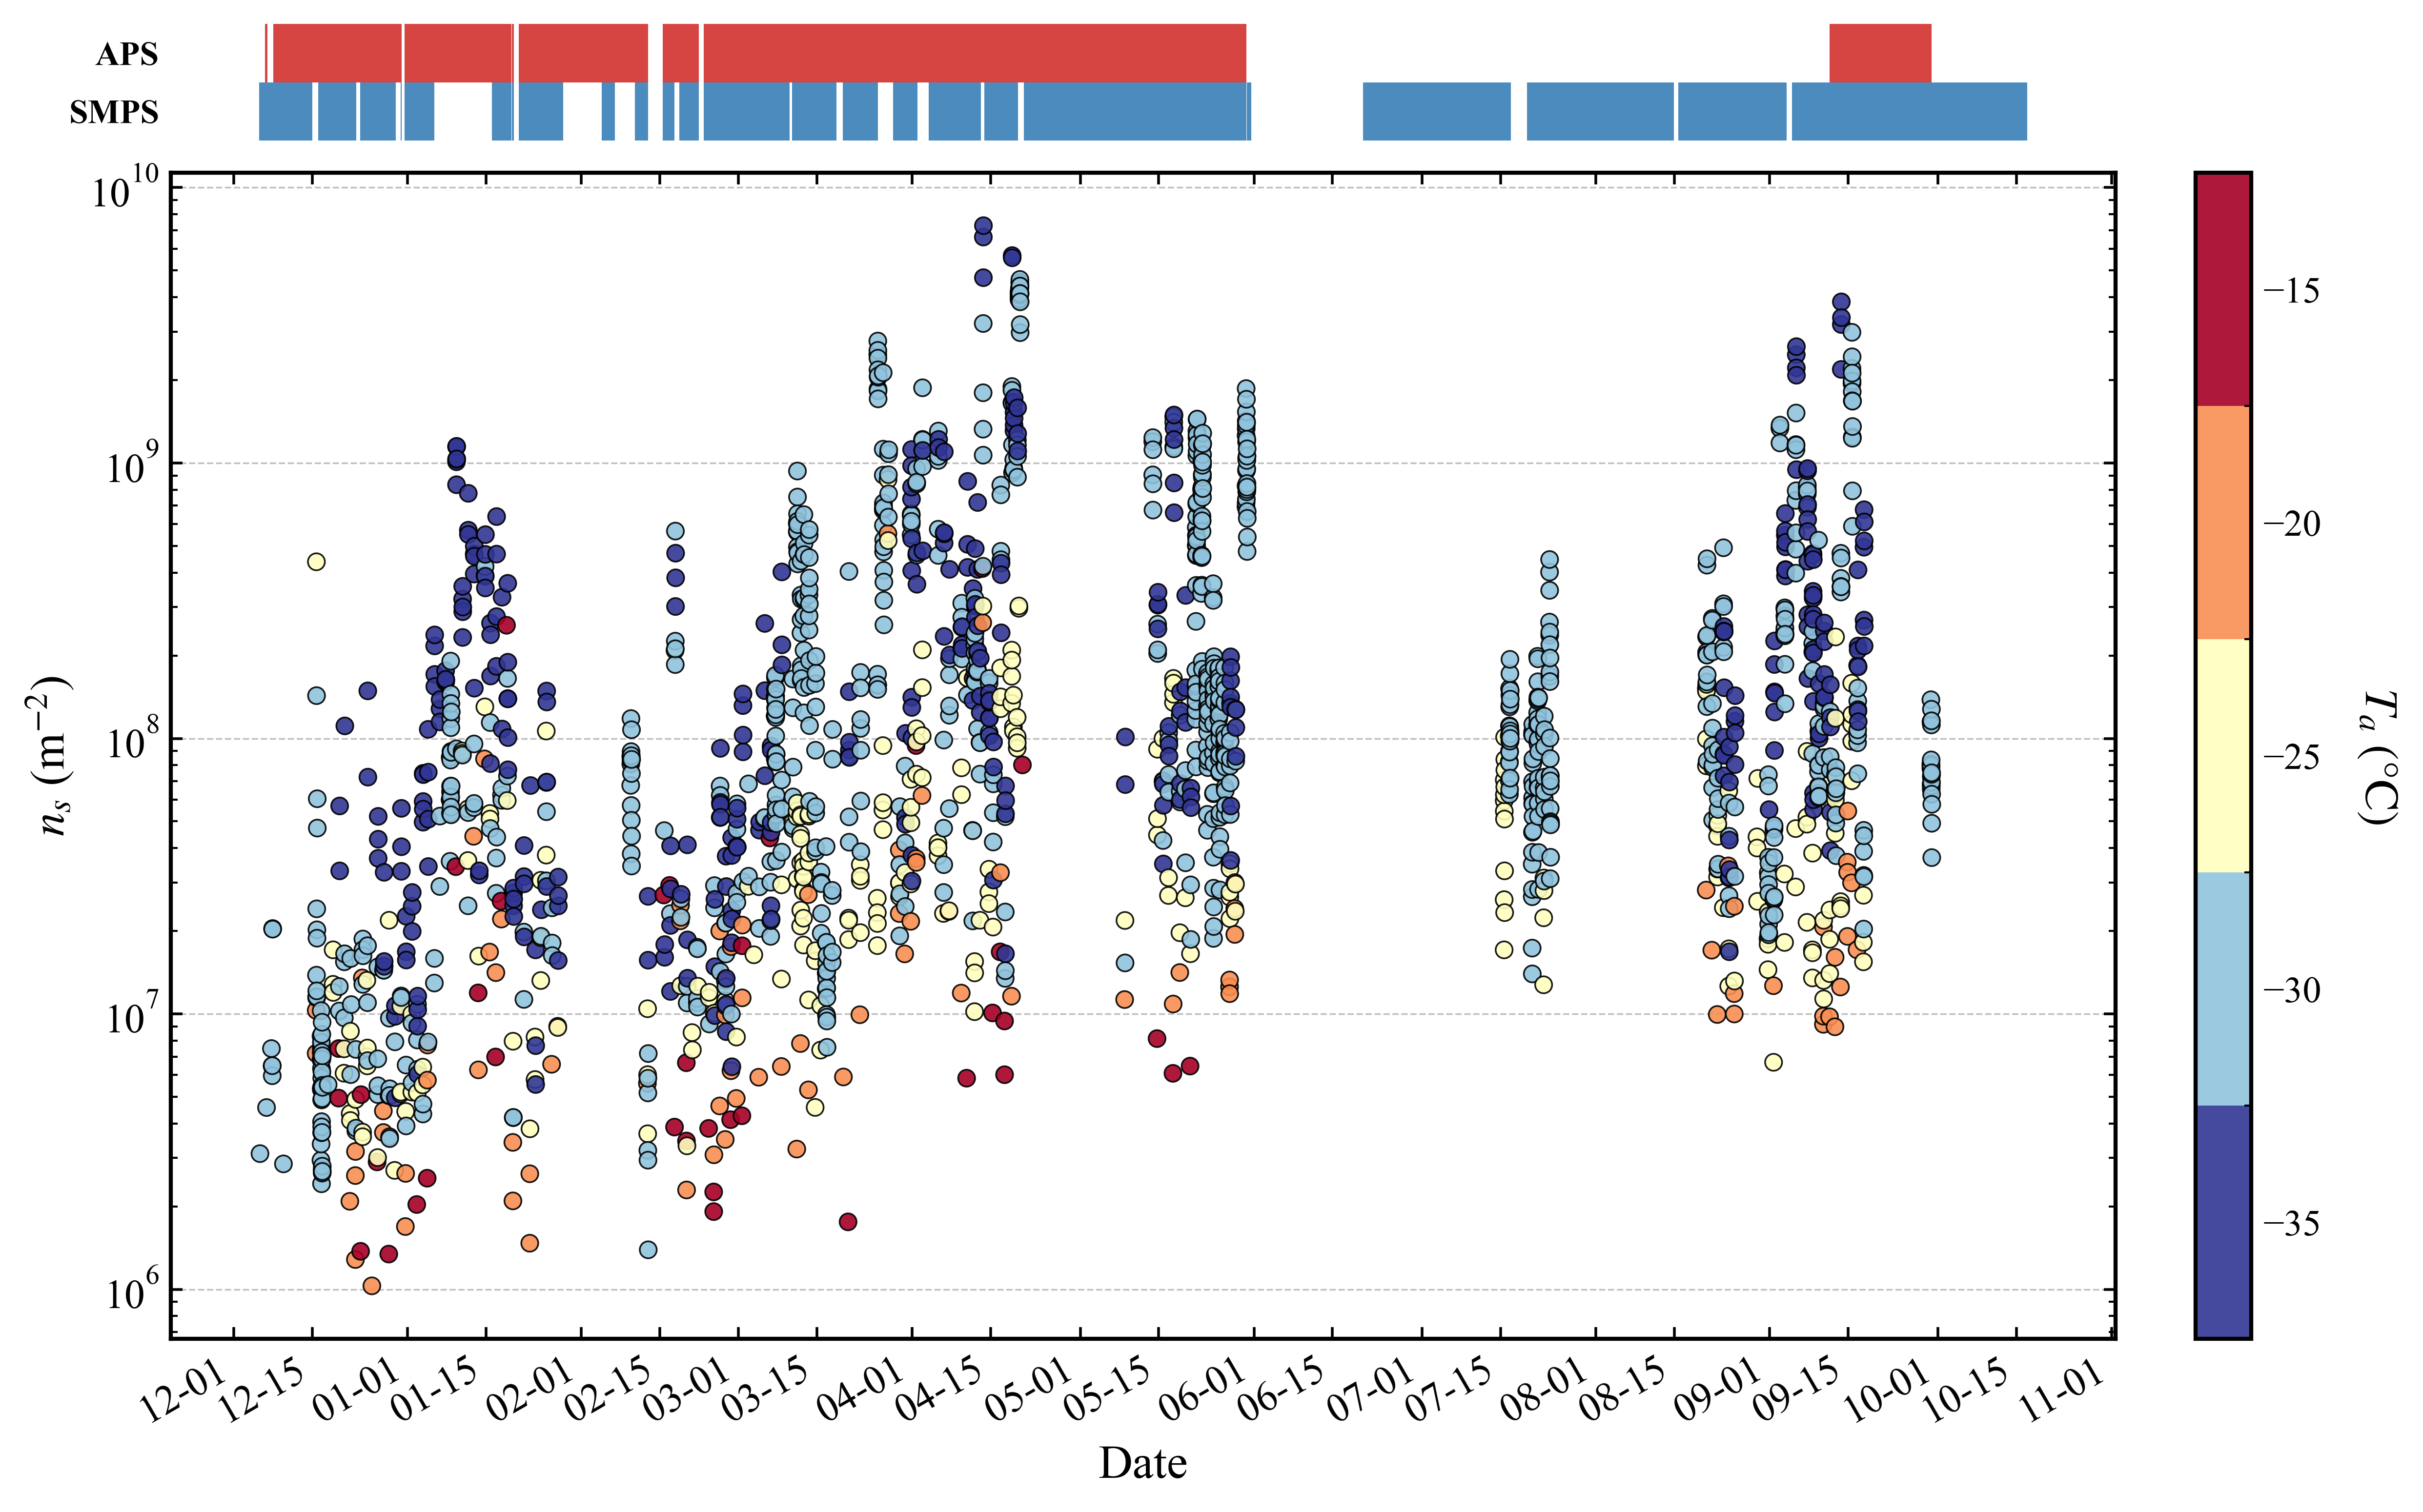

In [2]:
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker

# ==================== 1. 数据读取 ====================
final_psd_df = pd.read_csv(r"D:\Coding\Data\Lanzhou_aerosol\SMPS+APS\final_psd(v1.0.1).csv", index_col=0, parse_dates=True)
status_df = pd.read_csv(r"D:\Coding\Data\Lanzhou_aerosol\SMPS+APS\instrument_status(v1.0.1).csv", index_col=0, parse_dates=True)
result = pd.read_csv(r"D:\Coding\Data\Lanzhou_aerosol\SMPS+APS\INP+ns(v1.0.1).csv", parse_dates=['Date'])
status_smps = status_df['status_smps']
status_aps = status_df['status_aps']

result = result[result['Is_Significant'] == True].copy() # 只保留显著的数据点

# ==================== 2. 全局绘图风格设置 (论文级) ====================
config = {
    "font.family": 'serif',
    "font.serif": ['Times New Roman'],  # 论文标准字体
    "mathtext.fontset": 'stix',         # 数学公式字体与 Times 匹配
    "font.size": 12,
    "axes.linewidth": 1.2,              # 边框加粗
    "xtick.direction": 'in',            # 刻度向内
    "ytick.direction": 'in',
    "xtick.top": True,                  # 上下左右都有刻度
    "ytick.right": True,
    "xtick.minor.visible": False,        # 不显示次刻度
    "ytick.minor.visible": False
}
plt.rcParams.update(config)

# ==================== 3. 布局定义 ====================
# 使用 GridSpec 将画布分为 2行 x 2列
# 第一列放主图，第二列放 Colorbar (宽度很窄)
# 第一行放 Status，第二行放 Main Plot
fig = plt.figure(figsize=(11, 7), dpi=500) # 提高分辨率
gs = fig.add_gridspec(2, 2, 
                      width_ratios=[35, 1],   # 主图:色条宽度比
                      height_ratios=[1, 10],  # 状态条:主图高度比
                      wspace=0.08,            # 左右间距
                      hspace=0.05)            # 上下间距

ax_status = fig.add_subplot(gs[0, 0])
ax_main = fig.add_subplot(gs[1, 0], sharex=ax_status)
cax = fig.add_subplot(gs[1, 1])       # Colorbar 专用轴

# ==================== 4. 绘制顶部仪器状态条 ====================
dt_median = final_psd_df.index.to_series().diff().median()
bar_width = (dt_median.total_seconds() / 86400) * 1.02 

# 选用更柔和专业的颜色
c_smps = '#4B8BBE' # 柔和蓝
c_aps = '#D64541'  # 柔和红

ax_status.bar(final_psd_df.index[status_smps], height=1, bottom=0, 
              width=bar_width, color=c_smps, edgecolor='none', align='center')
ax_status.bar(final_psd_df.index[status_aps], height=1, bottom=1, 
              width=bar_width, color=c_aps, edgecolor='none', align='center')

# 美化状态条
ax_status.set_ylim(0, 2)
ax_status.set_yticks([0.5, 1.5])
ax_status.set_yticklabels(['SMPS', 'APS'], fontsize=10, fontweight='bold')
ax_status.tick_params(left=False, right=False, labelbottom=False, bottom=False, top=False) # 隐藏刻度线
# 只保留左侧文字，隐藏边框
for spine in ['top', 'right', 'left', 'bottom']:
    ax_status.spines[spine].set_visible(False)
ax_status.tick_params(left=False, bottom=False) 
# ==================== 5. 绘制主散点图 ====================

# --- 颜色映射逻辑 ---
# 温度点: -35, -30, -25, -20, -15
# 区间边界: [-37.5, -32.5, -27.5, -22.5, -17.5, -12.5]
bounds = [-37.5, -32.5, -27.5, -22.5, -17.5, -12.5]
# 使用 Spectral_r (反转光谱色): 红(暖) -> 蓝(冷)
# 也可以用 'RdYlBu_r'
cmap = plt.get_cmap('RdYlBu_r', 5) 
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# 绘制散点
sc = ax_main.scatter(result['Date'], result['n_s'], 
                     c=result['T_a(°C)'], cmap=cmap, norm=norm, 
                     s=25, alpha=0.9, edgecolors='black', linewidth=0.5, zorder=3)

# 设置坐标轴标签 (使用 LaTeX 格式)
ax_main.set_ylabel(r"$n_s$ ($\mathrm{m}^{-2}$)", fontsize=14)
ax_main.set_xlabel("Date", fontsize=14)
ax_main.set_yscale('log')

# 设置 X 轴日期格式
ax_main.xaxis.set_major_locator(mdates.DayLocator(bymonthday=[1, 15]))
ax_main.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(ax_main.xaxis.get_majorticklabels(), rotation=30, ha='right') # 旋转标签防止重叠

# 添加网格线 (灰色虚线，不抢眼)
ax_main.grid(which='major', axis='y', linestyle='--', linewidth=0.5, color='gray', alpha=0.5)

# ==================== 6. 绘制右侧离散 Colorbar ====================
cbar = plt.colorbar(sc, cax=cax, ticks=[-35, -30, -25, -20, -15])
cbar.set_label(r'$T_a \ (\degree \mathrm{C})$', fontsize=14, labelpad=10, rotation=270, va='bottom')
# 将 Colorbar 的 ticks 放在色块中心，并设置字体
cbar.ax.tick_params(labelsize=11, length=0) # length=0 隐藏刻度线，只留数字

plt.show()